## Reading the Knapsack file data

In [1]:
# Function to read the input file and extract the number of items, capacity, values, and weights
def read_file(path):
    # Initializing empty lists to store values and weights
    value_list = []
    weight_list = []
    with open(path) as f:    
        num_items, capacity = map(int, f.readline().split())
        for line in range(int(num_items)):
            (value, weight) = map(int,f.readline().split())
            value_list.append(value)
            weight_list.append(weight)
    return (num_items, capacity, value_list, weight_list)

In [2]:
# Reading the input file and extracting the number of items, capacity, values, and weights
# Note: Please change the path here for the input file you want to read.
(num_items, capacity, value_list, weight_list) = read_file("../data/100_995")
print(f'Number of Items: {num_items}, Capacity of bag: {capacity}')
print(f'Values are: {value_list}')
print(f'Weights are: {weight_list}')

Number of Items: 100, Capacity of bag: 995
Values are: [482, 257, 286, 517, 404, 713, 45, 924, 873, 160, 1, 838, 40, 58, 676, 627, 766, 862, 405, 923, 379, 461, 612, 133, 813, 97, 908, 165, 996, 623, 220, 298, 157, 723, 144, 48, 129, 148, 35, 644, 632, 272, 1040, 977, 312, 778, 567, 965, 1, 616, 569, 628, 493, 76, 733, 575, 288, 775, 723, 912, 64, 354, 565, 210, 922, 775, 566, 934, 626, 742, 194, 485, 483, 617, 876, 653, 896, 652, 220, 727, 900, 563, 56, 157, 280, 537, 284, 920, 124, 239, 459, 931, 504, 910, 382, 795, 485, 351, 289, 865]
Weights are: [485, 326, 248, 421, 322, 795, 43, 845, 955, 252, 9, 901, 122, 94, 738, 574, 715, 882, 367, 984, 299, 433, 682, 72, 874, 138, 856, 145, 995, 529, 199, 277, 97, 719, 242, 107, 122, 70, 98, 600, 645, 267, 972, 895, 213, 748, 487, 923, 29, 674, 540, 554, 467, 46, 710, 553, 191, 724, 730, 988, 90, 340, 549, 196, 865, 678, 570, 936, 722, 651, 123, 431, 508, 585, 853, 642, 992, 725, 286, 812, 859, 663, 88, 179, 187, 619, 261, 846, 192, 261, 514,

## Importing the Required packages

In [3]:
import random
import math
import numpy as np
from deap import base, creator, tools

In [4]:
# Maintaining the size of individual chromosome to be equal to the number of items in the knapsack problem
IND_SIZE = num_items
# Defining the population size for UMDA
POPULATION_SIZE = 50
# Defining the number of generations for UMDA
NUM_OF_GENERATION = 1000
# Number of selected individuals used to calculate the probability vector
UMDA_SELECTION_SIZE = 10
# Violating the capacity of the bag will incur a penalty, and this factor determines how much penalty will be applied
VIOLATION_FACTOR = sum(value_list) + 1
# Calculating the elite size based on the population size, ensuring it is at least 1
ELITE_SIZE = max(1, int(0.05*POPULATION_SIZE))

### Helper functions

In [12]:
# Evaluation Strategy for each individual chromosome in the population
def do_evaluation(individual):
    # Calcualting the bag value and weight for a individual
    (total_bag_value, total_bag_weight) = calculate_value_and_weight(individual)
    # Caclulating the vilation value
    violation = max(0,  total_bag_weight - capacity)
    # Final Fitness vlaue calculation
    fitness = total_bag_value - VIOLATION_FACTOR * (violation)
    return (fitness,)

# Function to calculate value and weight for one individual chromosome in the population
def calculate_value_and_weight(individual):
    value, weight = 0, 0
    # Iterating through each item in the individual chromosome to calculate the total value and weight
    for index, item in enumerate(individual):
        value += item * value_list[index]
        weight += item * weight_list[index]

    return (value, weight)

### Registering Functions and Creating Types

In [6]:
# Creating Fitness and Individual Class
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Registering function with the toolbox
toolbox = base.Toolbox()

# Defining the Individual and Population structure for UMDA
toolbox.register("attr_binary", random.choice, [0, 1])
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_binary, n=IND_SIZE)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
# Evaluation: Custom Method for evaluation
toolbox.register("evaluate", do_evaluation)

### UMDA Algorithm

In [14]:
# Seed list for 5 random UMDA runs
ga_seeds_list = [42, 52, 62, 72, 82]

# A list of lists storing fitness of best 5 individuals in each generation for each UMDA run
convergence_data = list()
run_best_fitness = list()

# Iterating through each UMDA run with different seeds
for ga_index, ga_seed in enumerate(ga_seeds_list):
    # Setting the seed using an integer
    random.seed(ga_seed)

    convergence_data.append([])
    
    # Initializing an initial population
    initial_population = toolbox.population(POPULATION_SIZE)

    # Evaluating fitness for each individual
    for individual in initial_population:
        individual.fitness.values = toolbox.evaluate(individual)
    
    # Iterating through each generation for the current UMDA run
    for gen_index in range(NUM_OF_GENERATION):

        new_population = list()

        # Performing Elitism so that we have the best individual carried forward
        elites = tools.selBest(initial_population, ELITE_SIZE)
        elites = list(map(toolbox.clone, elites))
        new_population.extend(elites)


        # Select M best individuals according to fitness
        selected_individuals = tools.selBest(initial_population, UMDA_SELECTION_SIZE)

        # Assign rank-based weights to selected individuals
        weights = [UMDA_SELECTION_SIZE - rank for rank in range(UMDA_SELECTION_SIZE)]

        # Calculate the weighted probability of each bit being 1
        probability_vector = []

        for bit_index in range(IND_SIZE):
            weighted_ones = sum(weights[index] * individual[bit_index] for index, individual in enumerate(selected_individuals))

            probability = weighted_ones / sum(weights)
            probability_vector.append(probability)
        

        while len(new_population) < POPULATION_SIZE:
            new_individual = creator.Individual([
                1 if random.random() < probability_vector[bit_index] else 0
                for bit_index in range(IND_SIZE)
            ])

            # Evaluate the new individual
            new_individual.fitness.values = toolbox.evaluate(new_individual)
            new_population.append(new_individual)

        # Updating the population for the next generation
        initial_population = new_population

        best_fitness = tools.selBest(new_population, 1)[0].fitness.values[0]
        convergence_data[ga_index].append(best_fitness)

    # Printing the best individual and its corresponding value and weight for the current UMDA run
    best_individual = tools.selBest(initial_population, 1)[0]
    run_best_fitness.append(best_individual.fitness.values[0])
    (best_value, best_weight) = calculate_value_and_weight(best_individual)
    
    print(f'UMDA Run: {ga_index + 1}, Best value: {best_value}, Best Weight: {best_weight}, Fitness: {best_individual.fitness.values[0]}, Bag Capacity: {capacity}')

# Calculate mean and standard deviation of the best fitness values from the 5 runs
mean_fitness = np.mean(run_best_fitness)
std_fitness = np.std(run_best_fitness, ddof=1)

print(f'\nMean fitness: {mean_fitness:.6f}')
print(f'Standard deviation: {std_fitness:.6f}')

UMDA Run: 1, Best value: 1240, Best Weight: 1023, Fitness: -1429980.0, Bag Capacity: 995
UMDA Run: 2, Best value: 1650, Best Weight: 1658, Fitness: -33887595.0, Bag Capacity: 995
UMDA Run: 3, Best value: 1178, Best Weight: 982, Fitness: 1178.0, Bag Capacity: 995
UMDA Run: 4, Best value: 2959, Best Weight: 2989, Fitness: -101920351.0, Bag Capacity: 995
UMDA Run: 5, Best value: 3222, Best Weight: 2915, Fitness: -98137578.0, Bag Capacity: 995

Mean fitness: -47074865.200000
Standard deviation: 50221861.362236


### Convergence Curve Plotting and Data Calculation

In [8]:
# Calculating the average fitness of best 5 individuals across generations for all UMDA runs
x_list = np.arange(1, NUM_OF_GENERATION + 1)
y_list = []

# Iterating through each generation
for col in range(NUM_OF_GENERATION):
    # Calculating the sum of fitness values
    sum_across_each_generation = 0
    # Iterating through each UMDA run to calculate the sum of fitness values for the current generation
    for ga_run in range(len(convergence_data)):
        sum_across_each_generation += convergence_data[ga_run][col]
    y_list.append(sum_across_each_generation / len(convergence_data))

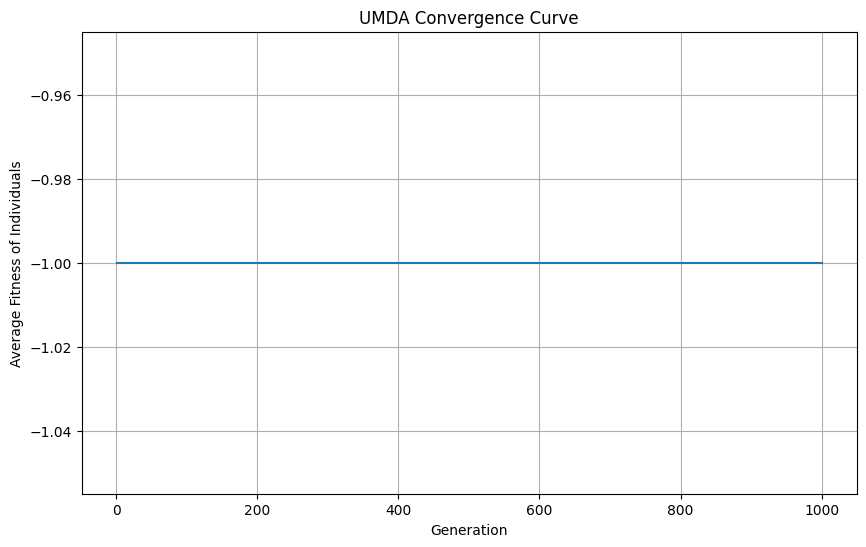

In [9]:
# Plotting the convergence curve for the average fitness of best 5 individuals across generations
import matplotlib.pyplot as plt

# Plot convergence curve
plt.figure(figsize=(10, 6))

plt.plot(x_list, y_list)

plt.xlabel("Generation")
plt.ylabel("Average Fitness of Individuals")
plt.title("UMDA Convergence Curve")

plt.grid(True)
plt.show()